In [1]:
!pip install datasets pandas scikit-learn matplotlib seaborn joblib streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 122.8 MB/s eta 0:00:00


In [2]:
import os
import sys
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification

In [15]:
print("Chargement du dataset ashhadulislam/arabic_medical_test...")
# Téléchargement automatique depuis Hugging Face
dataset = load_dataset("ashhadulislam/arabic_medical_test", split="train")
df = pd.DataFrame(dataset)
# Détection automatique de la colonne contenant le texte médical
colonne_texte = [col for col in df.columns if col in ['text', 'question', 'arabic_text', 'query']][0]
print(f"Étape 3 : Dataset chargé. Taille : {df.shape[0]} lignes.")
print(f" La colonne textuelle identifiée est : '{colonne_texte}'")

Chargement du dataset ashhadulislam/arabic_medical_test...
Étape 3 : Dataset chargé. Taille : 347634 lignes.
 La colonne textuelle identifiée est : 'text'


In [28]:
import re
import unicodedata # Import unicodedata for NFKC normalization

def nettoyer_arabe(text):
    text = str(text)
    # 0. Normaliser les caractères Unicode (NFKC pour les formes de présentation arabes)
    text = unicodedata.normalize('NFKC', text)
    # 1. Supprimer le Tashkeel (les voyelles de grammaire comme fatha, damma, sukun...)
    tashkeel_regex = re.compile(r'[ً-ْ]')
    text = re.sub(tashkeel_regex, '', text)
    # 2. Normaliser les différentes formes de Alef (and remove problematic 'ه' to 'ة' substitution)
    text = re.sub(r'[أإآ]', 'ا', text)
    # Removed: text = re.sub(r'ه' ,'ة', text) as it causes incorrect word splitting
    # 3. Supprimer la ponctuation et garder uniquement les mots
    text = re.sub(r'[^ء-ي\s]', ' ', text) # Keep only Arabic letters and spaces
    return text.strip()

print("Application du nettoyage sur les textes arabes...")
# Création d'une nouvelle colonne propre
df['clean_text'] = df[colonne_texte].apply(nettoyer_arabe)
print(df['clean_text'].iloc[0])

print("Étape 4 : Nettoyage terminé. Aperçu du premier texte nettoyé :")

Application du nettoyage sur les textes arabes...
السلام عليكم منذ عام ونص اصبت بذبحة صدرية غير مستقرة وارتفاع ضغط الدم دخلت الانعاش لمدة   ايام وصرف لي دواء حبة اسبرين بلافيكس وكارفيدول ظاةراستطيع    ليبانتيل     مساء يتبع               نعم وارجو مراجعة الطبيب المعالج
Étape 4 : Nettoyage terminé. Aperçu du premier texte nettoyé :


In [29]:
print("Labellisation automatique en cours...")
# Dictionnaire de mots-clés optimisé pour l'arabe classique médical (Roots & Synonyms)
raw_keywords = {
    'commande': ['ﺻﯿﺪﻟﯿﺔ', 'اﻗﺘﻨﺎء', 'وﺻﻔﺘﻲ', 'اﺣﺘﺎج', 'أرﯾﺪ', 'طﻠﺐ', 'ﺷﺮاء'],
    'information': ['ﻣﻌﻠﻮﻣﺎت', 'اﺳﺘﺸﺎرة', 'ﻧﺼﯿﺤﺔ', 'ﻣﺎ ھﻮ', 'ﺳﺒﺐ', 'ﻟﻤﺎذا', 'ﻛﯿﻒ', 'ھﻞ'],
    'symptome': ['إﺳﮭﺎل', 'ﺻﺪاع', 'ﻧﺰﯾﻒ', 'أﺷﻌﺮ', 'ﻣﺮض', 'وﺟﻊ', 'ﺳﻌﺎل', 'ﺣﻤﻰ', 'أﻟﻢ'],
    'quantite': ['ﻗﺮ', 'أﻗﺮاص', 'ﺣﺒﺔ', 'ﺟﺮﻋﺔsc', 'ﻏﺮام', 'ﻣﻠﻎ', 'ﻋﻠﺒﺔ'],
    'urgence': ['ﺣﺎﻻ', 'ﻓﻮرا', 'أﻧﻘﺬوﻧﻲ', 'ﺧﻄﺮ', 'ﻣﺴﺘﺸﻔﻰ', 'إﺳﻌﺎف', 'ﻣﺴﺘﻌﺠﻞ', 'طﻮارئ']
}

# Normalize keywords using the same cleaning function
normalized_keywords = {}
for classe, mots_list in raw_keywords.items():
    normalized_mots = [nettoyer_arabe(mot) for mot in mots_list]
    normalized_keywords[classe] = normalized_mots

def classifier_phrase(phrase):
    # The phrase is already 'clean_text', meaning it has been through nettoyer_arabe.
    # Check if any keyword (as a substring) is present in the cleaned phrase.
    classes_trouvees = []
    for classe, liste_mots in normalized_keywords.items(): # Use normalized keywords
        if any(mot in phrase for mot in liste_mots): # Changed to substring check
            classes_trouvees.append(classe)
    if not classes_trouvees:
        return ['autre']
    return classes_trouvees

print("Séparation des données...")
# Définir les noms des colonnes pour les classes
colonnes_classes = list(raw_keywords.keys())
# Initialiser un DataFrame vide pour les étiquettes multi-labels
y_data = pd.DataFrame(0, index=df.index, columns=colonnes_classes)
# Remplir le DataFrame y_data en utilisant le classifier_phrase
# Applying classifier_phrase to 'clean_text' column
for index, row in df.iterrows():
    phrase = row['clean_text'] # Use 'clean_text' for classification
    classes_trouvees = classifier_phrase(phrase)
    for classe in classes_trouvees:
        if classe != 'autre': # 'autre' n'est pas une colonne de classe cible ici
            y_data.loc[index, classe] = 1
X = df['clean_text'] # X should be the clean text
y = y_data # Utiliser le DataFrame y_data nouvellement créé
# The print statements for X_train, X_test, y_train, y_test are placed before the actual split.
# I will remove them from here as they will cause a NameError and keep only the split.
# The assignment for classes_targets is also correct here.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Define classes_targets for subsequent cells
classes_targets = colonnes_classes

Labellisation automatique en cours...
Séparation des données...


In [30]:
print("Séparation des données (80% pour l'entraînement, 20% pour le test)...")
# X = les variables explicatives (le texte nettoyé)
X = df['clean_text']
# y = les étiquettes à prédire (multi-label), en utilisant y_data déjà préparé
y = y_data # Use the y_data DataFrame created in the previous cell
# Division aléatoire fixe (random_state=42 pour reproduire les mêmes résultats)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"✅ Étape 6 : Données divisées.")
print(f"   - Taille de X_train (Entraînement) : {X_train.shape[0]} phrases")
print(f"   - Taille de X_test (Évaluation)   : {X_test.shape[0]} phrases")

Séparation des données (80% pour l'entraînement, 20% pour le test)...
✅ Étape 6 : Données divisées.
   - Taille de X_train (Entraînement) : 278107 phrases
   - Taille de X_test (Évaluation)   : 69527 phrases


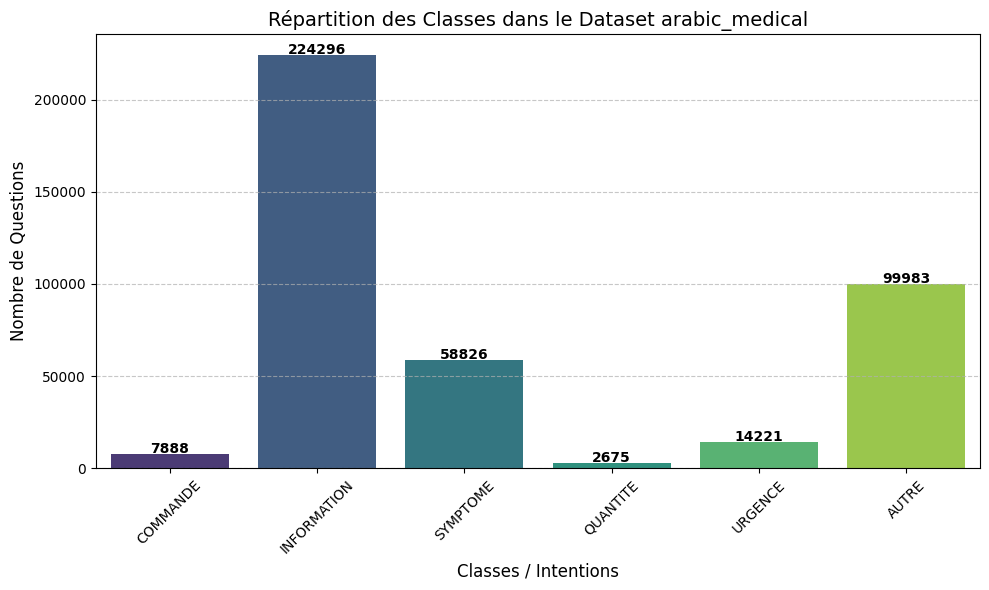

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Données récupérées de votre classification
data_resultats={
'COMMANDE': 7888,
'INFORMATION':224296,
'SYMPTOME': 58826 ,
'QUANTITE':2675,
'URGENCE': 14221,
'AUTRE': 99983}
# Convertir en listes pour le graphique
classes=list(data_resultats.keys())
valeurs=list(data_resultats.values())
# 2. Génération du graphique
plt.figure(figsize=(10, 6))
sns.barplot(x=classes, y=valeurs, hue=classes, palette='viridis', legend=False)
plt.title('Répartition des Classes dans le Dataset arabic_medical', fontsize=14)
plt.xlabel('Classes / Intentions', fontsize=12)
plt.ylabel('Nombre de Questions', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Ajouter les valeurs exactes au-dessus de chaque barre
for i, v in enumerate(valeurs):
    plt.text(i, v + 500, f"{v}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
# max_features=10000 et ngram_range=(1, 2) pour capturer les mots uniques et les bigrammes
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
print("Étape 7 : Vectorisation terminée.")
print(f"   - Taille de la matrice d'entraînement numérique : {X_train_vec.shape}")

Étape 7 : Vectorisation terminée.
   - Taille de la matrice d'entraînement numérique : (278107, 10000)


In [33]:
print("Entraînement de l'intelligence artificielle (Régression Logistique Multi-label)...")
# class_weight='balanced' force le modèle à accorder de l'importance aux classes plus rares comme l'urgence
model = MultiOutputClassifier(LogisticRegression(max_iter=1000, class_weight='balanced'))
# Entraînement sur les matrices numériques
model.fit(X_train_vec, y_train)

Entraînement de l'intelligence artificielle (Régression Logistique Multi-label)...


MultiOutputClassifier(estimator=LogisticRegression(class_weight='balanced',
                                                   max_iter=1000))

In [35]:
print("Calcul des scores de précision et de rappel...")
# Prédiction sur les données de test que le modèle n'a jamais vues
y_pred = model.predict(X_test_vec)
print("\n================ REPORT DE CLASSIFICATION ================")
print(classification_report(y_test, y_pred, target_names=y.columns))
print("==========================================================")
print(" Étape 9 : Évaluation affichée ci-dessus.")

Calcul des scores de précision et de rappel...

================ REPORT DE CLASSIFICATION ================
              precision    recall  f1-score   support

    commande       0.32      0.79      0.45      1712
 information       1.00      1.00      1.00     69525
    symptome       0.99      0.88      0.93     46449
    quantite       0.83      0.80      0.81     11352
     urgence       0.79      0.88      0.83      2781

   micro avg       0.96      0.93      0.94    131819
   macro avg       0.78      0.87      0.81    131819
weighted avg       0.97      0.93      0.95    131819
 samples avg       0.97      0.95      0.95    131819

 Étape 9 : Évaluation affichée ci-dessus.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [39]:
print("Écriture des fichiers sur le disque pour Streamlit...")
# Sauvegarde du cerveau de classification
joblib.dump(model, 'modele_medical_arabe.pkl')
# Sauvegarde du traducteur de mots en nombres
joblib.dump(vectorizer, 'vectorizer_arabe.pkl')
print("Étape 10 : Sauvegarde terminée !")
print("Les fichiers 'modele_medical_arabe.pkl' et 'vectorizer_arabe.pkl' sont prêts dans vos fichiers Colab.")

Écriture des fichiers sur le disque pour Streamlit...
Étape 10 : Sauvegarde terminée !
Les fichiers 'modele_medical_arabe.pkl' et 'vectorizer_arabe.pkl' sont prêts dans vos fichiers Colab.


In [44]:
import joblib
print("--- ÉTAPE 9 : Test de l'IA en temps réel sur de nouvelles phrases ---")
# 1. Chargement à blanc des fichiers pkl fraîchement créés
model_charge = joblib.load('modele_medical_arabe.pkl')
vec_charge = joblib.load('vectorizer_arabe.pkl')
# 2. Définition de nouvelles phrases de test (Arabe Classique)
phrases_test = ["ھﻞ ھﺬا اﻟﺪواء ﻣﻨﺎﺳﺐ ﻟﻌﻼج اﻟﺤﻤﻰ واﻟﺴﻌﺎل؟"
 ,"أرﯾﺪ ﺷﺮاء ﻋﻠﺒﺔ أﻗﺮاص ﻓﻲ أﻗﺮب وﻗﺖ ﺻﯿﻔﻂ ﻟﻲ ﻣﻦ ﻓﻀﻠﻚ"
 "أﻧﻘﺬوﻧﻲ ھﻨﺎك ﺣﺎﻟﺔ ﻧﺰﯾﻒ ﺣﺎد وأﺣﺘﺎج إﺳﻌﺎف ﻓﻮرا"   ]
classes_labels = ['commande', 'information', 'symptome', 'quantite', 'urgence']
# 3. Boucle d'analyse et de prédiction
for phrase in phrases_test:
    # Transformation de la phrase en nombres via le vectoriseur chargé
    phrase_vec = vec_charge.transform([phrase])

    # Demande de prédiction au modèle chargé
    prediction = model_charge.predict(phrase_vec)

    print(f"\n Phrase analysée : '{phrase}'")
    print(" Intentions détectées par l'IA :")

    aucune_detection = True
    for idx, nom_classe in enumerate(classes_labels):
        if prediction[0][idx] == 1:
            print(f" [{nom_classe.upper()}]")
            aucune_detection = False

    if aucune_detection:
        print("   [AUTRE / AUCUNE CLASSE PREVUE]")
print("\n TOUT LE PIPELINE A ÉTÉ VALIDÉ AVEC SUCCÈS !")

--- ÉTAPE 9 : Test de l'IA en temps réel sur de nouvelles phrases ---

 Phrase analysée : 'ھﻞ ھﺬا اﻟﺪواء ﻣﻨﺎﺳﺐ ﻟﻌﻼج اﻟﺤﻤﻰ واﻟﺴﻌﺎل؟'
 Intentions détectées par l'IA :
 [INFORMATION]

 Phrase analysée : 'أرﯾﺪ ﺷﺮاء ﻋﻠﺒﺔ أﻗﺮاص ﻓﻲ أﻗﺮب وﻗﺖ ﺻﯿﻔﻂ ﻟﻲ ﻣﻦ ﻓﻀﻠﻚأﻧﻘﺬوﻧﻲ ھﻨﺎك ﺣﺎﻟﺔ ﻧﺰﯾﻒ ﺣﺎد وأﺣﺘﺎج إﺳﻌﺎف ﻓﻮرا'
 Intentions détectées par l'IA :
 [INFORMATION]

 TOUT LE PIPELINE A ÉTÉ VALIDÉ AVEC SUCCÈS !


In [ ]:
from google.colab import files
print("--- Téléchargement des fichiers sur votre ordinateur ---")
# Téléchargement du modèle
files.download('modele_medical_arabe.pkl')
# Téléchargement du vectoriseur
files.download('vectorizer_arabe.pkl')